# 1. Constructing a government zero curve from market quotes

## Objective

A yield curve is not observed. What the market publishes is a set of prices and
quoted rates on instruments with different cash flow patterns: bills that pay
once, bonds that pay coupons twice a year, swaps that exchange fixed for
floating. Each of those quotes is consistent with many different zero curves on
its own. Only taken together do they pin down a single discount function.

This notebook builds that discount function for the Swedish government market as
of 24 July 2026, using the sequential bootstrap implemented in
`yieldcurve.curves.bootstrap`. It then reproduces one bootstrapped point by hand
to show that nothing in the library is doing anything the reader cannot check
with a calculator.

## Data

Two Riksbank series are used, both retrieved from the public Riksbank statistics
API and stored in the committed snapshot `data/snapshots/2026-07-24/`:

| File | Series | Instruments |
|---|---|---|
| `riksbank_bills.csv` | SETB1MBENCHC, SETB3MBENCH, SETB6MBENCH | Treasury bills, 1M / 3M / 6M |
| `riksbank_gov_benchmarks.csv` | SEGVB2Y, SEGVB5Y, SEGVB7Y, SEGVB10Y | Government benchmark
yields |

Full provenance, including retrieval dates and series identifiers, is recorded in
`DATA_SOURCES.md`.

Two gaps in this data are worth stating at the outset, because they constrain
what the curve can legitimately say. First, the 12-month bill series
(SETB12MBENCH) was discontinued in 2010 and has no current replacement, so there
is no direct quote between 6 months and 2 years. Second, the Riksbank publishes
benchmark yields at 2, 5, 7 and 10 years only. The 1, 15, 20 and 30 year points
that appear in some vendor curves are absent from the public API. Any value the
curve reports at 15 or 30 years is therefore an extrapolation, not a fit to an
observed quote, and is treated as such throughout this repository.

In [1]:
# ## Theory
#
# The bootstrap is a sequence of one-dimensional root-finds, one per instrument,
# solved in maturity order. The key insight is that each step has exactly one
# unknown.
#
# Every instrument's market price is the sum of discounted cash flows:
#
# $$ V = \sum_i c_i \, P(0, t_i) $$
#
# where $c_i$ are cash flows and $P(0, t_i)$ are discount factors. A bill has one
# cash flow and therefore depends on only $P$ at its own maturity. A bond with
# coupons has cash flows at multiple dates. The bootstrap exploits ordering by
# maturity: when pricing instrument $k$, every cash flow except the last one falls
# at a date $t_i < T_k$ where $P(0, t_i)$ is already known from instruments
# $1 \ldots k-1$. That leaves a single unknown, the discount factor $P(0, T_k)$
# at the instrument's maturity, and a single equation to invert.
#
# **The solution is unique.** The market price of a bond is strictly monotone
# decreasing in its discount factor: as $P$ falls the price falls, and vice versa.
# This monotonicity guarantees that any bracketing root-finder converges to a
# unique solution without requiring a good starting guess.
#
# Between instrument maturities, the curve is silent. The market has provided no
# information. The interpolation rule fills those gaps. This is critical, because
# a real instrument may pay on dates where no quote exists. For example, a
# 10-year bond pays 20 coupons over 10 years. Of those 20 dates, at most seven
# coincide with the pillar maturities. At the other 13 dates, the discount factor
# comes from interpolation, not from the market. Changing the interpolation rule
# changes those intermediate values, which changes the instrument's repriced value
# at the pillar, which changes the solved discount factor at the pillar in the
# opposite direction to keep the price at 100. This means a bootstrapped pillar is
# not a pure market observable; it is a market observable contaminated by the
# interpolation rule applied to the earlier cash flows.
#
# Day-count conventions and compounding conventions add a layer of complexity:
# they are the map between a quoted rate and a discount factor. Swedish treasury
# bills are quoted on simple interest, ACT/360. The curve itself uses continuous
# compounding, ACT/365F. The two conventions describe the same price but express
# it as different rates. Simple ACT/360 over roughly three months is not
# numerically equal to continuous ACT/365 over the same period, even though both
# are correct. This repository converts explicitly at every boundary rather than
# treating rates as interchangeable numbers.

In [2]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np

from yieldcurve.conventions import DayCount, year_fraction
from yieldcurve.curves.build import sek_government_curve
from yieldcurve.curves.interpolation import InterpMethod
from yieldcurve.curves.protocol import curve_time
from yieldcurve.market.snapshot import Snapshot

ASOF = date(2026, 7, 24)
snapshot = Snapshot(ASOF)

bills = snapshot.load("riksbank_bills")
bonds = snapshot.load("riksbank_gov_benchmarks")

print("Treasury bills")
print(bills.to_string(index=False))
print("\nGovernment benchmark yields")
print(bonds.to_string(index=False))

Treasury bills
tenor maturity_date    rate
   1M    2026-08-24 0.01933
   3M    2026-10-24 0.01974
   6M    2027-01-24 0.02043

Government benchmark yields
tenor maturity_date   yield
   2Y    2028-07-24 0.02478
   5Y    2031-07-24 0.02756
   7Y    2033-07-24 0.02848
  10Y    2036-07-24 0.03012


In [3]:
# ## Methodology
#
# ### What the bootstrap solves
#
# The discount factor $P(0,T)$ is the price today of one krona paid with certainty
# at time $T$. Every instrument in the curve is a claim on a set of dated cash
# flows $c_i$ at times $t_i$, and its market price is
#
# $$ V = \sum_i c_i \, P(0, t_i) $$
#
# The bootstrap exploits the fact that the instruments can be ordered by maturity.
# Take them shortest first. When instrument $k$ is priced, every cash flow except
# the final one falls on a date where $P$ is already known from instruments
# $1 \ldots k-1$. That leaves a single unknown, the discount factor at the final
# maturity, and a single equation. The library solves it with Brent's method rather
# than in closed form, because the interpolation scheme makes the intermediate
# discount factors a non-linear function of the unknown endpoint.
#
# ### Where interpolation enters
#
# Coupon dates rarely coincide with the maturities of the pillar instruments. A ten
# year bond pays on twenty dates, of which at most a handful are pillars. Values at
# the other dates come from interpolation, so the interpolation rule is part of the
# pricing model, not a cosmetic choice made afterwards. This library interpolates
# on $\log P(0,t)$, which is equivalent to interpolating on $-t \cdot z(t)$ where
# $z$ is the continuously compounded zero rate. Notebook 02 compares the three
# available rules; here the default, Hagan-West monotone convex, is used
# throughout.
#
# ### Bills and the money market convention
#
# Swedish treasury bills are quoted on a simple-interest ACT/360 basis. A bill
# maturing at $T$ with quoted rate $r$ and accrual factor $\tau$ has price
#
# $$ V = \frac{100}{1 + r \tau} \qquad \Rightarrow \qquad P(0,T) = \frac{1}{1 + r\tau} $$
#
# The compounded convention used for the zero curve is different, so the quoted
# rate and the zero rate at the same maturity will not be numerically equal. That
# difference is a convention artefact and not a spread.
#
# ### Benchmark yields as par bonds
#
# The Riksbank publishes benchmark *yields*, not prices. A benchmark yield is the
# yield of a hypothetical bond trading at par. Since a bond priced at par has
# coupon equal to yield by construction, the quote can be converted into a
# bootstrappable instrument by building a bond whose coupon equals the quoted
# yield and whose target price is exactly 100. This is what
# `sek_government_curve` does internally: it passes the same number as both the
# instrument coupon and the target rate.

In [4]:
curve = sek_government_curve(snapshot, ASOF, method=InterpMethod.MONOTONE_CONVEX)

labels = list(bills["tenor"]) + list(bonds["tenor"])
maturities = [
    date.fromisoformat(str(d)) for d in list(bills["maturity_date"]) + list(bonds["maturity_date"])
]
pillars = [curve_time(ASOF, m) for m in maturities]

print(f"{'tenor':>6} {'maturity':>12} {'t (years)':>10} {'P(0,t)':>12} {'zero (%)':>10}")
for label, maturity, t in zip(labels, maturities, pillars, strict=True):
    print(
        f"{label:>6} {maturity!s:>12} {t:>10.4f} {curve.df(t):>12.6f} {100 * curve.zero(t):>10.4f}"
    )

 tenor     maturity  t (years)       P(0,t)   zero (%)
    1M   2026-08-24     0.0849     0.998338     1.9582
    3M   2026-10-24     0.2521     0.994981     1.9964
    6M   2027-01-24     0.5041     0.989666     2.0606
    2Y   2028-07-24     2.0027     0.952170     2.4472
    5Y   2031-07-24     5.0027     0.872463     2.7272
    7Y   2033-07-24     7.0055     0.820802     2.8188
   10Y   2036-07-24    10.0082     0.741048     2.9944


In [5]:
# ## Hand check of one bootstrapped point
#
# The three month bill is the cleanest instrument to verify, because it has a
# single cash flow and therefore no dependence on interpolation. Its quoted rate is
# 1.974 per cent on an ACT/360 basis. The check below recomputes the discount
# factor from the quote alone and compares it with the value the bootstrap
# produced.

In [6]:
three_month = bills.loc[bills["tenor"] == "3M"].iloc[0]
quoted = float(three_month["rate"])
maturity = date.fromisoformat(str(three_month["maturity_date"]))

tau = year_fraction(ASOF, maturity, DayCount.ACT_360)
by_hand = 1.0 / (1.0 + quoted * tau)
from_curve = curve.df(curve_time(ASOF, maturity))

print(f"quoted simple rate      {quoted:.6f}  (ACT/360)")
print(f"accrual factor tau      {tau:.6f}")
print(f"P(0,T) by hand          {by_hand:.10f}")
print(f"P(0,T) from bootstrap   {from_curve:.10f}")
print(f"difference              {abs(by_hand - from_curve):.2e}")
print()
print(f"quoted simple rate      {100 * quoted:.4f} %")
print(f"continuous zero rate    {100 * curve.zero(curve_time(ASOF, maturity)):.4f} %")

quoted simple rate      0.019740  (ACT/360)
accrual factor tau      0.255556
P(0,T) by hand          0.9949806543
P(0,T) from bootstrap   0.9949806543
difference              0.00e+00

quoted simple rate      1.9740 %
continuous zero rate    1.9964 %


In [7]:
# The two discount factors are identical in double precision: the printed
# difference is exactly zero. The bootstrap reproduces the money market convention
# rather than approximating it, which is expected, because for a single cash flow
# instrument the root find has a closed form solution and lands on it.
#
# The quoted rate and the zero rate differ by about 2 basis points, 1.9740 against
# 1.9964 per cent. This is the convention artefact described above: simple ACT/360
# interest over roughly a quarter is not the same quantity as a continuously
# compounded ACT/365 rate, even when both describe the same price. Conflating the
# two is a common source of small, persistent, hard to locate errors in curve code,
# which is why this repository converts explicitly at every boundary rather than
# treating rates as interchangeable numbers.

In [8]:
# ## Results
#
# Three views of the same object are plotted below. They contain identical
# information and are not independent checks of each other, but each makes a
# different property visible.

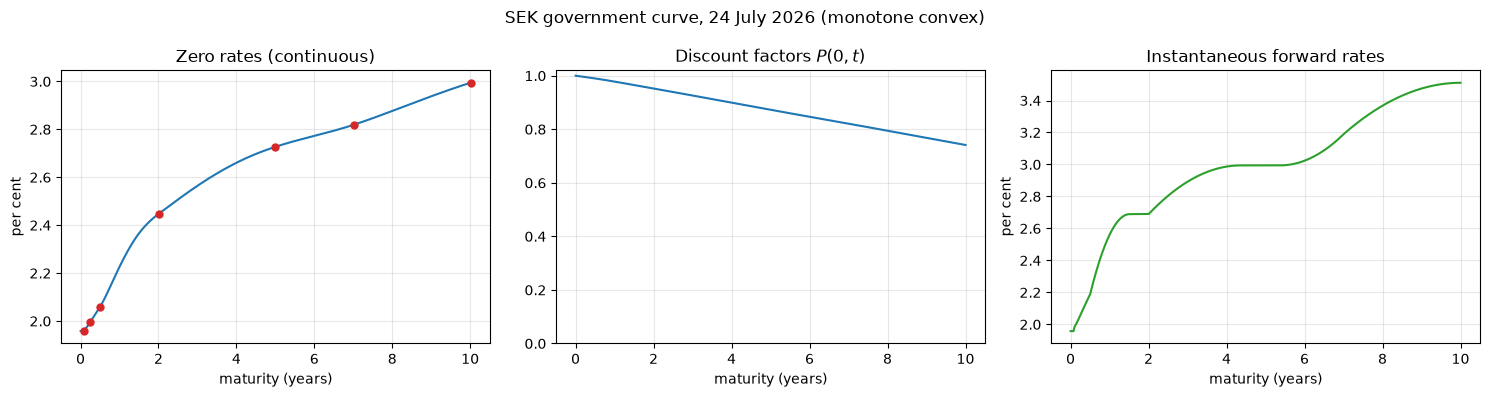

In [9]:
grid = np.linspace(1 / 365, 10.0, 400)

zeros = np.array([curve.zero(t) for t in grid])
dfs = np.array([curve.df(t) for t in grid])
fwds = np.array([curve.instantaneous_fwd(t) for t in grid])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(grid, 100 * zeros, color="#1f77b4")
axes[0].scatter(pillars, [100 * curve.zero(t) for t in pillars], color="#d62728", zorder=3, s=25)
axes[0].set_title("Zero rates (continuous)")
axes[0].set_xlabel("maturity (years)")
axes[0].set_ylabel("per cent")

axes[1].plot(grid, dfs, color="#1f77b4")
axes[1].set_title("Discount factors $P(0,t)$")
axes[1].set_xlabel("maturity (years)")
axes[1].set_ylim(0, 1.02)

axes[2].plot(grid, 100 * fwds, color="#2ca02c")
axes[2].set_title("Instantaneous forward rates")
axes[2].set_xlabel("maturity (years)")
axes[2].set_ylabel("per cent")

for ax in axes:
    ax.grid(alpha=0.3)
fig.suptitle("SEK government curve, 24 July 2026 (monotone convex)")
fig.tight_layout()
plt.show()

In [10]:
# ## Interpretation
#
# **The zero curve is upward sloping across the whole observed range.** It rises
# from 1.96 per cent at the one month pillar to 2.99 per cent at ten years, a slope
# of about 103 basis points. The red markers are the seven pillar maturities, the
# points where an actual quote constrains the curve. Between them the curve is an
# interpolation, and beyond ten years it would be an extrapolation.
#
# **The discount factor curve is monotonically decreasing and starts at one.** Both
# properties are required for the curve to be arbitrage free with non-negative
# rates: a claim on a krona further away cannot be worth more than a claim on a
# krona sooner, and a claim payable immediately is worth its face. The bootstrap
# does not impose these as constraints. They emerge from the input quotes, which
# means that a violation would be diagnostic of bad data rather than a bug in the
# solver.
#
# **The forward curve is the most informative and the least stable of the three.**
# The instantaneous forward $f(t) = -\partial \log P(0,t) / \partial t$ is a
# derivative of the fitted object, so it amplifies whatever the interpolation rule
# does between pillars. A zero curve that looks smooth to the eye can have a
# forward curve with visible steps or oscillation. This sensitivity is the reason
# forward curves are the standard diagnostic for interpolation quality, and it is
# the subject of notebook 02.
#
# ## Regulatory context
#
# Curve construction sits inside a supervisory framework rather than being a purely
# technical exercise.
#
# Under **IFRS 13** an instrument valued from observable market inputs is
# classified as Level 2, whereas one valued using significant unobservable inputs
# is Level 3, which carries materially heavier disclosure obligations. The
# distinction is not abstract here. Between 6 months and 2 years this curve has no
# quote at all, and past 10 years it has no quote either. Values reported in those
# regions depend on the interpolation and extrapolation rule, which is an
# unobservable input. Documenting where the pillars actually are is part of
# substantiating a Level 2 classification.
#
# Under the **Basel Committee's standards for interest rate risk in the banking
# book** (BCBS d368, April 2016), banks are required to be able to reprice their
# banking book under prescribed shocks and to document the yield curve methodology
# used. The requirement is on the process, not on a specific interpolation scheme;
# what supervisors expect is that the choice is stated, justified and applied
# consistently. Notebook 05 applies the BCBS d368 scenarios to this curve.
#
# Under **CRR Article 105** on prudent valuation, and the associated EBA regulatory
# technical standards, firms must hold additional valuation adjustments where
# market prices are uncertain. A curve region with no observable pillar is exactly
# the circumstance the market price uncertainty AVA is designed to capture.
#
# ## Limitations
#
# The bootstrap fits its inputs exactly, which is a strength for pricing
# instruments included in the bootstrap set and a weakness for pricing others.
# A single stale or outlier quote bends the curve in its neighbourhood with
# nothing to smooth it away. The curve reflects the interpolation rule's choice
# between curves equally consistent with the quotes: where data are sparse the
# choice is consequential. The 18-month region between the 6-month bill and 2-year
# bond is an example; notebook 02 measures what three defensible rules say there.
# Maturities beyond 10 years are extrapolated, not fit to any quote, and should
# not be relied upon for risk calculations.
#
# ## Summary
#
# A discount curve was bootstrapped from three Riksbank treasury bill quotes and
# four government benchmark yields as of 24 July 2026. The three month point was
# reproduced by hand from the quoted simple ACT/360 rate and matched the solver
# exactly in double precision.
#
# The resulting curve is upward sloping, with a monotone decreasing discount
# function, and is constrained by observed quotes only at seven maturities. The
# regions between 6 months and 2 years, and beyond 10 years, reflect the
# interpolation rule rather than market data, and any risk number computed there
# should be read with that in mind.